In [10]:
import numpy as np
from uncertainties import ufloat
from uncertainties import unumpy as unp
import numpy as np

In [90]:
# 20 Schwingungen
Reaktionszeit = 0.2
Zeit = [43.39,43.70,43.61]

def Fehler_des_Mittelwerts(array):
    return np.std(array,ddof=1) / np.sqrt(3)

def Time_array_to_ufloat(array, Error):
    return ufloat(np.average(array), np.sqrt(Fehler_des_Mittelwerts(array)**2 + Error**2))

T = Time_array_to_ufloat(Zeit, Reaktionszeit) / 20
f_0 = 1 / T
omega_0 = 2 * np.pi * f_0

omega_0


/usr/lib/python3.14/site-packages/uncertainties/core.py:526: FutureWarning: AffineScalarFunc.error_components() is currently an instance method. This method is deprecated. In a future release it will be replaced with an instance property by the same name. It will be accessed by AffineScalarFunc.error_components (with no parentheses).
  return float(sqrt(sum(delta**2 for delta in self.error_components().values())))
/usr/lib/python3.14/site-packages/uncertainties/core.py:491: FutureWarning: AffineScalarFunc.derivatives() is deprecated. It will be removed in a future release.
  for variable, derivative in self.derivatives.items():


2.8844002940380657+/-0.014577147561313675

In [ ]:
# Dämpfung 40mA Zeit bis 5%
T_1 = 26

# D#mpfung 55mA

T_2 = 15

# Fehler:
Nullpunkt bei 2 statt bei 0 Grad

16


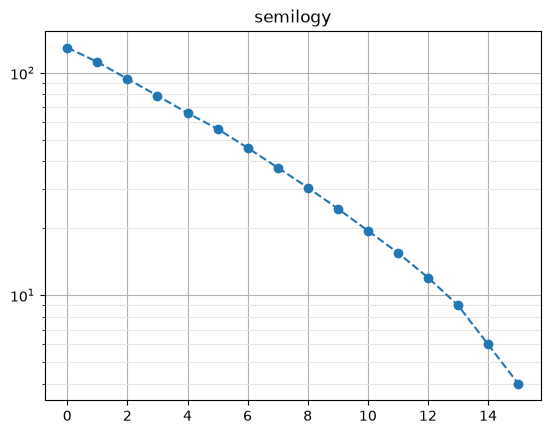

In [25]:
# 40 mA Dämpfung

Fehler_Amplitude = 1
# Zeit fehler ignoireirt weil im video von stoppuhr abgelesen

Amplitude = [130,112,94,79,66,56,46,37.5,30.5,24.5,19.5,15.5,12,9,6,4]
print(len(Amplitude))
import matplotlib.pyplot as plt
import numpy as np

fig, (ax1) = plt.subplots(1, 1)
# log x axis


# log y axis
x = np.arange(16)
ax1.semilogy(x, Amplitude, 'o--')
ax1.set(title='semilogy')
ax1.grid()
ax1.grid(which="minor", color="0.9")



In [91]:

T_half_40 = ufloat(3.4, 0.5) * T
dampening_40 = np.log(2) / T_half_40
print(dampening_40)

T_half_55 = ufloat(1.95, 0.2) * T
dampening_55 = np.log(2) / T_half_55
print(dampening_55)



0.094+/-0.014
0.163+/-0.017


/usr/lib/python3.14/site-packages/uncertainties/core.py:526: FutureWarning: AffineScalarFunc.error_components() is currently an instance method. This method is deprecated. In a future release it will be replaced with an instance property by the same name. It will be accessed by AffineScalarFunc.error_components (with no parentheses).
  return float(sqrt(sum(delta**2 for delta in self.error_components().values())))
/usr/lib/python3.14/site-packages/uncertainties/core.py:491: FutureWarning: AffineScalarFunc.derivatives() is deprecated. It will be removed in a future release.
  for variable, derivative in self.derivatives.items():


0.075    2.5
0.125    3
0.175    3.5
0.225    3.75
0.275    4
0.325    5.5
0.375    7.5
0.4    10.5
0.4125    13
0.425    17
0.4375    24.5
0.45    39
0.45625    42.5
0.4625    39.5
0.475    24
0.4875    16
0.525    8
0.575    5
0.625    3.5
0.675    2.5
0.725    2
0.775    2
0.825    1.5
0.875    1
0.925    1
1.0    1
--------
0.075    2.5
0.125    2.5
0.175    3
0.225    3.5
0.275    4
0.325    5
0.375    7
0.4    10
0.4125    12
0.425    14.5
0.4375    18
0.45    21
0.45625    22
0.4625    21
0.475    17
0.4875    13
0.525    7.5
0.575    4.5
0.625    3
0.675    2.5
0.75    2
0.875    1.5
1.0    1


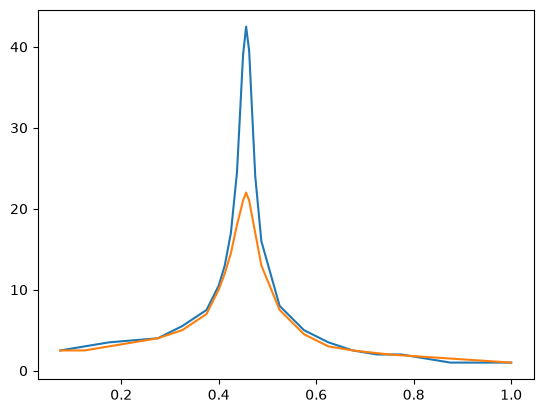

In [76]:
# 40 mA Dämpfung


# 4000 Hz -> 1Hz
Frequenz_40 = np.array([300,500,700,900,1100,1300,1500,1700,1900,2100,2300,2500,2700,2900,3100,3300,3500,3700,4000,
            1600,1650,1750,1800,1850,1950,1825]) / 4000
# Alle Messungen links
Fehler_Amplitude = 1 # (Skaleneinteilung 2)
Amplitude_40 = [2.5,3,3.5,3.75,4,5.5,7.5,17,24,8,5,3.5,2.5,2,2,1.5,1,1,1,
            10.5,13,24.5,39,39.5,16,42.5
            ]
xs, ys = zip(*sorted(zip(Frequenz_40, Amplitude_40)))

print("\n".join([str(float(x))+ "    " + str(y) for x,y in zip(xs,ys)]))
Frequenz_55 =  np.array([300,500,700,900,1100,1300,1500,1700,1900,2100,2300,2500,2700,3000,3500,4000,1600,1650,1750,1800,1850,1950,1825]) / 4000
Amplitude_55 = [2.5,2.5,3  ,3.5,4   ,5   ,7   ,14.5,17  ,7.5 ,4.5 ,3   ,2.5 ,2   ,1.5 ,1   ,10  ,12  ,18  ,21  ,21  ,13  ,22]
xs1, ys1 = zip(*sorted(zip(Frequenz_55, Amplitude_55)))
print("--------")

print("\n".join([str(float(x))+ "    " + str(y) for x,y in zip(xs1,ys1)]))

plt.plot(xs, ys)
plt.plot(xs1,ys1)

-0.02780621004905387


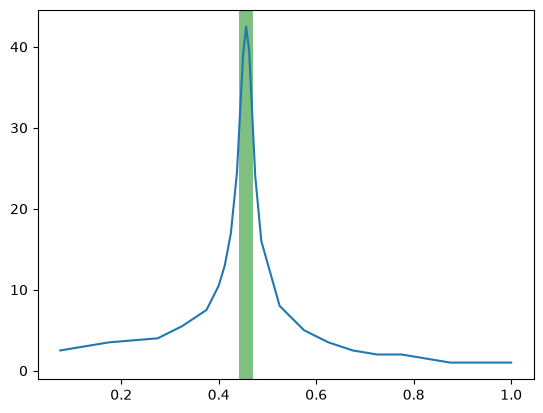

In [85]:
from scipy.interpolate import UnivariateSpline
spline = UnivariateSpline(xs, ys - np.max(ys) / np.sqrt(2), s=0)
r1, r2 = spline.roots() # find the roots
import pylab as pl
pl.plot(xs, ys)
pl.axvspan(r1, r2, facecolor='g', alpha=0.5)
print(r1 - r2)
pl.show()



-0.0503013633674006


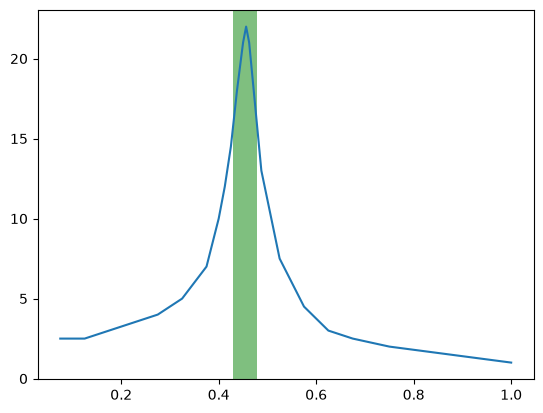

In [86]:
from scipy.interpolate import UnivariateSpline
spline = UnivariateSpline(xs1, ys1- np.max(ys1) / np.sqrt(2), s=0)
r1, r2 = spline.roots() # find the roots
import pylab as pl
pl.plot(xs1, ys1)
pl.axvspan(r1, r2, facecolor='g', alpha=0.5)
print(r1 - r2)
pl.show()



In [89]:
def Halbwertsbreite_zu_delta(H):
    return H * np.pi

print(Halbwertsbreite_zu_delta(0.05))

0.15707963267948966


# Phasenverschiebung
Bei Resonanz: Pendel um pi/2 nach motor
Kleine Frequenz: Keine Phasenverschiebung
Große Frequenz: pi


# 

In [101]:
# Resonance Amplification

b_max_40 = ufloat(42.5,1)
b_max_55 = ufloat(22,1)

b_zero_40 = ufloat(2.5,1)
b_zero_55 = ufloat(2.5,1)

delta_40 = omega_0 / 2 * b_zero_40 / b_max_40
delta_55 = omega_0 / 2 * b_zero_55 / b_max_55

def print_2d_uarray_as_typst_table(uarray):
    for row in uarray:
        print("".join(f"num(\"{str(x).replace("/","")}\")," for x in row))

print_2d_uarray_as_typst_table([
    [b_max_40, b_zero_40, delta_40],
    [b_max_55, b_zero_55, delta_55]])

delta_40,delta_55

num("42.5+-1.0"),num("2.5+-1.0"),num("0.085+-0.034"),
num("22.0+-1.0"),num("2.5+-1.0"),num("0.16+-0.07"),


(0.08483530276582546+/-0.03399548362700879,
 0.16388638034307193+/-0.06598165332272846)